In [1]:
!pip install git+https://github.com/k329272/kestrel -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install roboflow -q
from roboflow import Roboflow
from google.colab import userdata
rf = Roboflow(api_key=userdata.get("RoboflowAPIKey"))
project = rf.workspace(userdata.get("RoboflowWorkspace")).project(userdata.get("RoboflowProject"))
version = project.version(9)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to rock-paper-scissors-9 in yolov8:: 100%|██████████| 29057/29057 [00:02<00:00, 10446.52it/s]


{'class_loss': 0.9019502056901041, 'bbox_loss': 0.012761304199902682, 'total_loss': 0.9147115090159963}


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 45,  57,  85],
        [ 45,  57,  85],
        [ 44,  56,  84],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 44,  56,  84],
        [ 44,  56,  84],
        [ 43,  55,  83],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 43,  55,  83],
        [ 43,  55,  83],
        [ 42,  54,  82],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
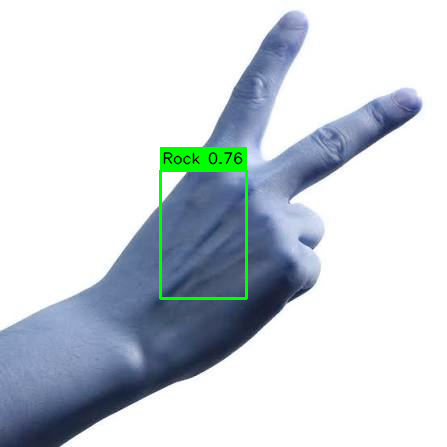

In [3]:
import kestrel
import yaml
from pathlib import Path

# Path to the data.yaml file
data_yaml_path = Path("./rock-paper-scissors-9/data.yaml")

# Load the data.yaml content
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Update paths if they are in the problematic format
for split_key in ['train', 'val', 'test']:
    if split_key in data_config and isinstance(data_config[split_key], str) and data_config[split_key].startswith('../'):
        data_config[split_key] = data_config[split_key][3:]

# Save the updated data.yaml content
with open(data_yaml_path, 'w') as f:
    yaml.safe_dump(data_config, f)

model = kestrel("kestrel26n.yaml")
print(model.train(data=data_yaml_path, epochs=16))
model.val()
results = model("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSHjNGIYkWtyGK8Ps366rtNj0g9HDontzqzcpY_Z5KYLQ&s=10")
results[0].plot()

In [4]:
from google.colab import runtime
runtime.unassign()